In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 05

<font color="yellow">

</font>



## Exercise 05.1
### Assignment

Use the Metropolis algorithm to sample $|\Psi_{1,0,0}(x,y,z)|^2$ and $|\Psi_{2,1,0}(x,y,z)|^2$ **in Cartesian coordinates** using, initially, an uniform transition probability $T(\vec{x}|\vec{y})$. Use the sampled positions to estimate $\left\langle r \right\rangle_{\Psi_{1,0,0}}$ and $\left\langle r \right\rangle_{\Psi_{2,1,0}}$. As usual, use data blocking and give an estimate of the statistical uncertainties.


Show a picture of your estimations of ${\left\langle r \right\rangle_{\Psi_{1,0,0}}}$ and ${\left\langle r \right\rangle_{\Psi_{2,1,0}}}$ and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^6$) as a function of the number of blocks, $N$</font>.

- Use Bohr radius units, $a_0$ for distances
- Choose the step of the uniform transition probability $T(\vec{x}|\vec{y})$ in order to obtain 50% of acceptance in both cases
- Choose a reasonable starting point in the 3D space and equilibrate your sampling before to start measuring the radius. What do you observe when you start very far from the origin?
- How large should be the number of Monte Carlo Metropolis steps in each block?
- If you use a multivariate normal transition probability ${T(\vec{x}|\vec{y})}$, i.e. a Gaussian for each coordinate, your results for </span> ${\left\langle r \right\rangle_{\Psi_{1,0,0}}}$ and  ${\left\langle r \right\rangle_{\Psi_{2,1,0}}}$  are equivalent?

### Solution

The code is structured similarly to all other simulations, that is three folders contained in the same folder `NSL_SIMULATOR`:
- `SOURCE`: contains source code. 
    - `main.cpp`: very similar to other exercises: I create and initialize the object needed, execute a double loop and then write the data. 
    - `Hydrogen.h` and `Hydrogen.cpp`: I built a class `Hydrogen`, inspired by the other exercises. Significant methods are:
        ```c++
        std::vector <double> _x, _y, _z;     // Coordinates history
        bool metro(double fraction);         // Perform Metropolis acceptance-rejection step
        double pdf(double x, double y, double z); // Return pdf
        ```
    - `random.h`and `random.cpp`
    - `Makefile`
- `INPUT`: manages the input
    - `input.dat`, `Primes`, `seed.in`
- `OUTPUT`: where data are saved

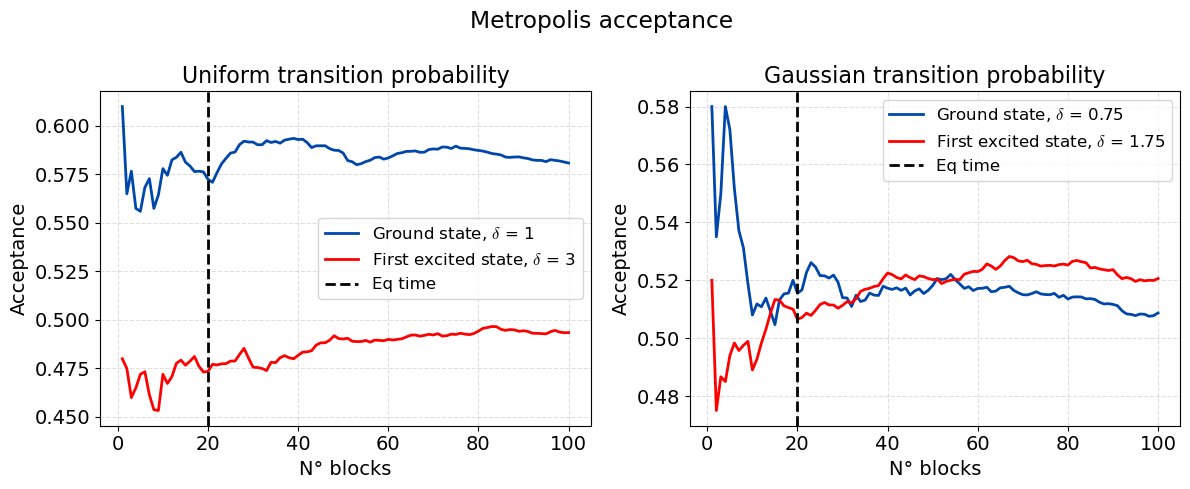

In [2]:
# Helper function to extract parameters from text files
def extract_parameter(filepath, keyword):
    with open(filepath, "r") as file:
        # Read the entire file and split it into a list of tokens
        tokens = file.read().split()
    try:
        # Find the index of the keyword and return the next element as an integer
        idx = tokens.index(keyword)
        return tokens[idx + 1]
    except ValueError:
        print(f"Error: Keyword '{keyword}' not found in {filepath}")
        return None
    except IndexError:
        print(f"Error: Value missing after keyword '{keyword}' in {filepath}")
        return None

folders_UNIF = ['OUTPUT_ground_unif',
                'OUTPUT_excited_unif']
folders_GAUSS = ['OUTPUT_ground_Gauss',
                'OUTPUT_excited_Gauss']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
fig.suptitle("Metropolis acceptance")


for folder_name in folders_UNIF:
    acceptance = np.loadtxt("NSL_SIMULATOR/" + folder_name + "/acceptance.dat")
    ax[0].plot(acceptance[:, 0], acceptance[:, 1])

labels = [f'Ground state, $\delta$ = {extract_parameter("NSL_SIMULATOR/" + folders_UNIF[0] + "/output.dat", "DELTA=")}',
          f'First excited state, $\delta$ = {extract_parameter("NSL_SIMULATOR/" + folders_UNIF[1] + "/output.dat", "DELTA=")}',
          'Eq time']

ax[0].set_title("Uniform transition probability")
ax[0].set_xlabel('N° blocks')
ax[0].set_ylabel('Acceptance')
ax[0].axvline(20, label='Eq time', linestyle='--', color='black')
ax[0].legend(labels, loc='best', frameon=True)

for folder_name in folders_GAUSS:
    acceptance = np.loadtxt("NSL_SIMULATOR/" + folder_name + "/acceptance.dat")
    ax[1].plot(acceptance[:, 0], acceptance[:, 1])

labels = [f'Ground state, $\delta$ = {extract_parameter("NSL_SIMULATOR/" + folders_GAUSS[0] + "/output.dat", "DELTA=")}',
          f'First excited state, $\delta$ = {extract_parameter("NSL_SIMULATOR/" + folders_GAUSS[1] + "/output.dat", "DELTA=")}', 
          'Eq time']

ax[1].set_title("Gaussian transition probability")
ax[1].set_xlabel('N° blocks')
ax[1].set_ylabel('Acceptance')
ax[1].axvline(20, linestyle='--', color='black', label='Eq time')
ax[1].legend(labels, loc='best', frameon=True)
    

fig.tight_layout()

Here i report the parameters needed to have a acceptance around 50%. 
- Uniform 
    - Ground state: $\delta = 1$
    - Excited state: $\delta = 3$
- Gaussian
    - Ground state: $\delta = 0.75$
    - Ground state: $\delta = 1.75$

An equilibration time of 2000 steps has been chosen. 

Text(0.5, 1.0, 'First excited state')

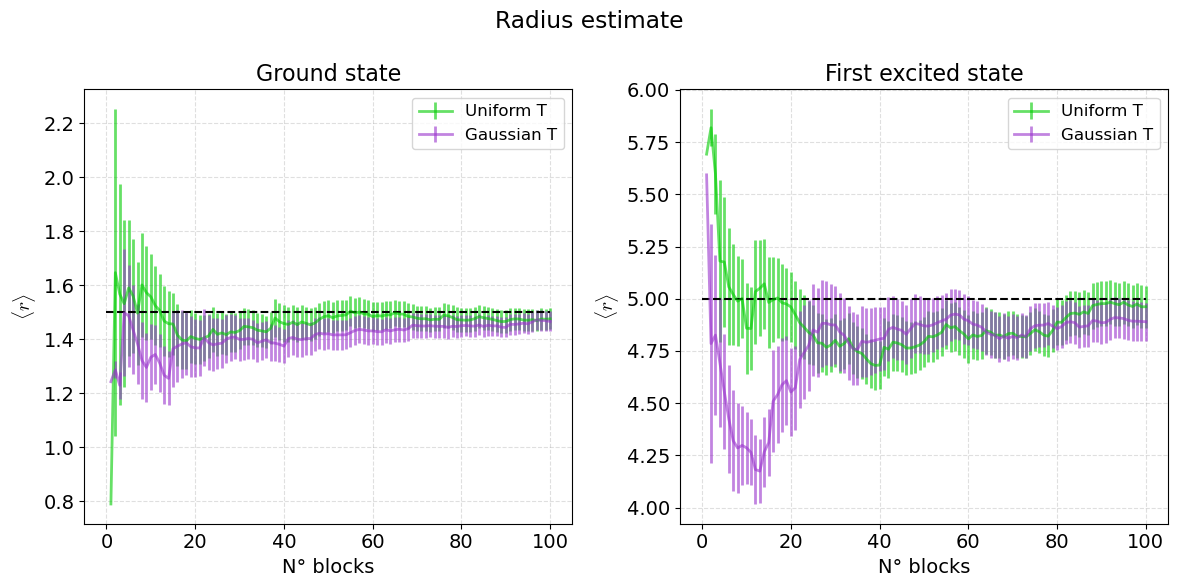

In [3]:
folders_UNIF = ['OUTPUT_eq_ground_unif',
                'OUTPUT_eq_excit_unif']
folders_GAUSS = ['OUTPUT_eq_ground_Gauss',
                'OUTPUT_eq_excit_Gauss']

labels = ['Uniform T', 'Gaussian T']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), tight_layout=True)
fig.suptitle("Radius estimate")

for i, folder_name in enumerate(folders_UNIF):
    data = np.loadtxt("NSL_SIMULATOR/" + folder_name + "/position.dat")
    ax[i].errorbar(data[:, 0], data[:, 2], data[:, 3], label=labels[i], color=light_colors[2], alpha=0.6)
for i, folder_name in enumerate(folders_GAUSS):
    data = np.loadtxt("NSL_SIMULATOR/" + folder_name + "/position.dat")
    ax[i].errorbar(data[:, 0], data[:, 2], data[:, 3], label=labels[i], color=light_colors[3], alpha=0.6)

    ax[i].set_xlabel('N° blocks')
    ax[i].set_ylabel(r'$\langle r \rangle$')
    ax[i].legend(labels, loc='best', frameon=True)

ax[0].hlines(1.5, 0, 100, linestyles='--', linewidth=1.5, color='black', label='Theoric')
ax[0].set_title('Ground state')

ax[1].hlines(5, 0, 100, linestyles='--', linewidth=1.5, color='black', label='Theoric')
ax[1].set_title('First excited state')



In the image it is possible to observe how both the uniform and gaussian sampling converge roughly to the same value. In particular, the excited state presents the biggest difference between values. However, despite some small differences, the behaviour of the two sampling methods is quite similar.

For these simulations I generated the starting point from a gaussian distibution in the three dimensions, with parameters $\mu_{start} = 0$ and $\sigma_{start} = 1$. This way the value is near the final value. To test how the algorithms perform when it starts far from the origin, I performed the same simulations, generating the initial point with parameters $\mu_{start} = 30$ and $\sigma_{start} = 0.1$, to be sure that it would have been generated near the position $(30, 30, 30)$. 

The plots are reported below.

Text(0.5, 1.0, 'First excited state')

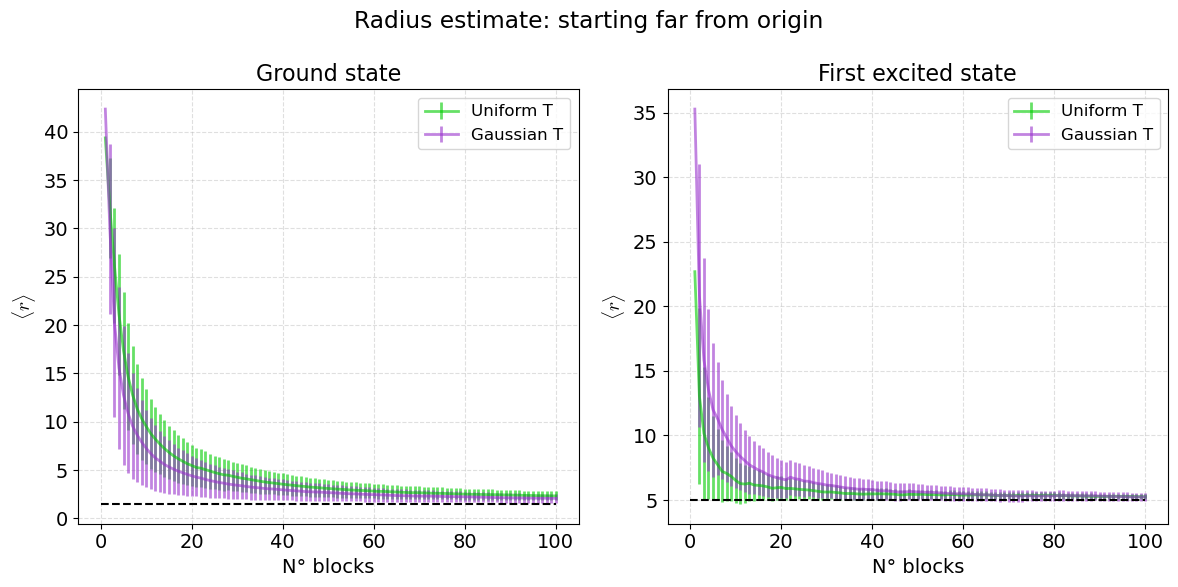

In [4]:
folders_UNIF = ['OUTPUT_ground_unif',
                'OUTPUT_excited_unif']
folders_GAUSS = ['OUTPUT_ground_Gauss',
                'OUTPUT_excited_Gauss']

labels = ['Ground state - Uniform T', 'First excited state - Uniform T', 'Ground state - Gauss T', 'First excited state - Gauss T']

labels = ['Uniform T', 'Gaussian T']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), tight_layout=True)
fig.suptitle("Radius estimate: starting far from origin")

for i, folder_name in enumerate(folders_UNIF):
    data = np.loadtxt("NSL_SIMULATOR/far_from_origin/" + folder_name + "/position.dat")
    ax[i].errorbar(data[:, 0], data[:, 2], data[:, 3], label=labels[i], color=light_colors[2], alpha=0.6)
for i, folder_name in enumerate(folders_GAUSS):
    data = np.loadtxt("NSL_SIMULATOR/far_from_origin/" + folder_name + "/position.dat")
    ax[i].errorbar(data[:, 0], data[:, 2], data[:, 3], label=labels[i], color=light_colors[3], alpha=0.6)

    ax[i].set_xlabel('N° blocks')
    ax[i].set_ylabel(r'$\langle r \rangle$')
    ax[i].legend(labels, loc='best', frameon=True)

ax[0].hlines(1.5, 0, 100, linestyles='--', linewidth=1.5, color='black', label='Theoric')
ax[0].set_title('Ground state')

ax[1].hlines(5, 0, 100, linestyles='--', linewidth=1.5, color='black', label='Theoric')
ax[1].set_title('First excited state')

As one could expect, the algorithm attracts rapidly the steps towards the origin, where the density probability function is much larger. Also in this second condition the two algorithms perform quite similarly. 

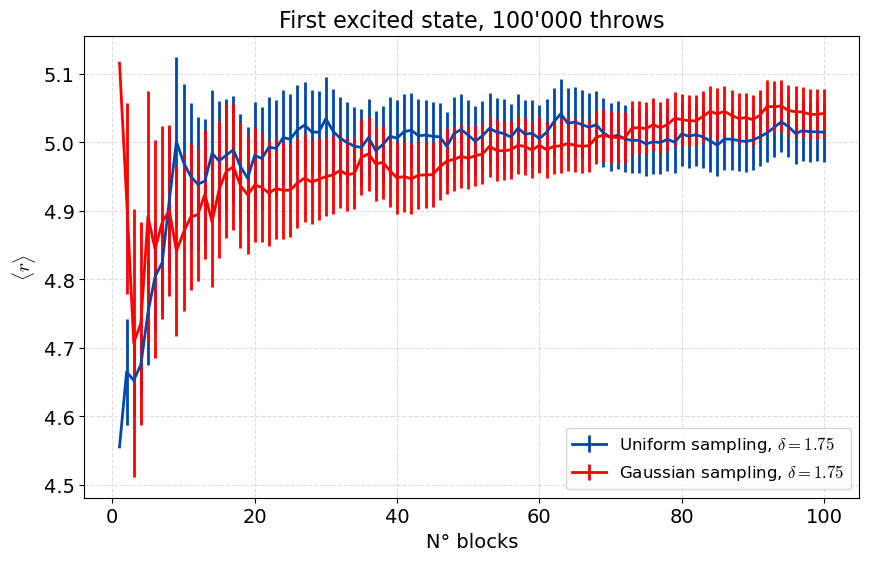

In [5]:
data1 = np.loadtxt("NSL_SIMULATOR/OUTPUT_1k_unif/position.dat")
plt.errorbar(data1[:, 0], data1[:, 2], data1[:, 3], label='Uniform sampling, $\delta = 1.75$')

data2 = np.loadtxt("NSL_SIMULATOR/OUTPUT_1k_gau/position.dat")
plt.errorbar(data2[:, 0], data2[:, 2], data2[:, 3], label='Gaussian sampling, $\delta = 1.75$')

plt.title(r"First excited state, 100'000 throws")
plt.xlabel('N° blocks')
plt.ylabel(r'$\langle r \rangle$')
plt.legend(loc='lower right', frameon=True)

fig.tight_layout()

/tmp/ipykernel_73052/1176094958.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('inferno_r')


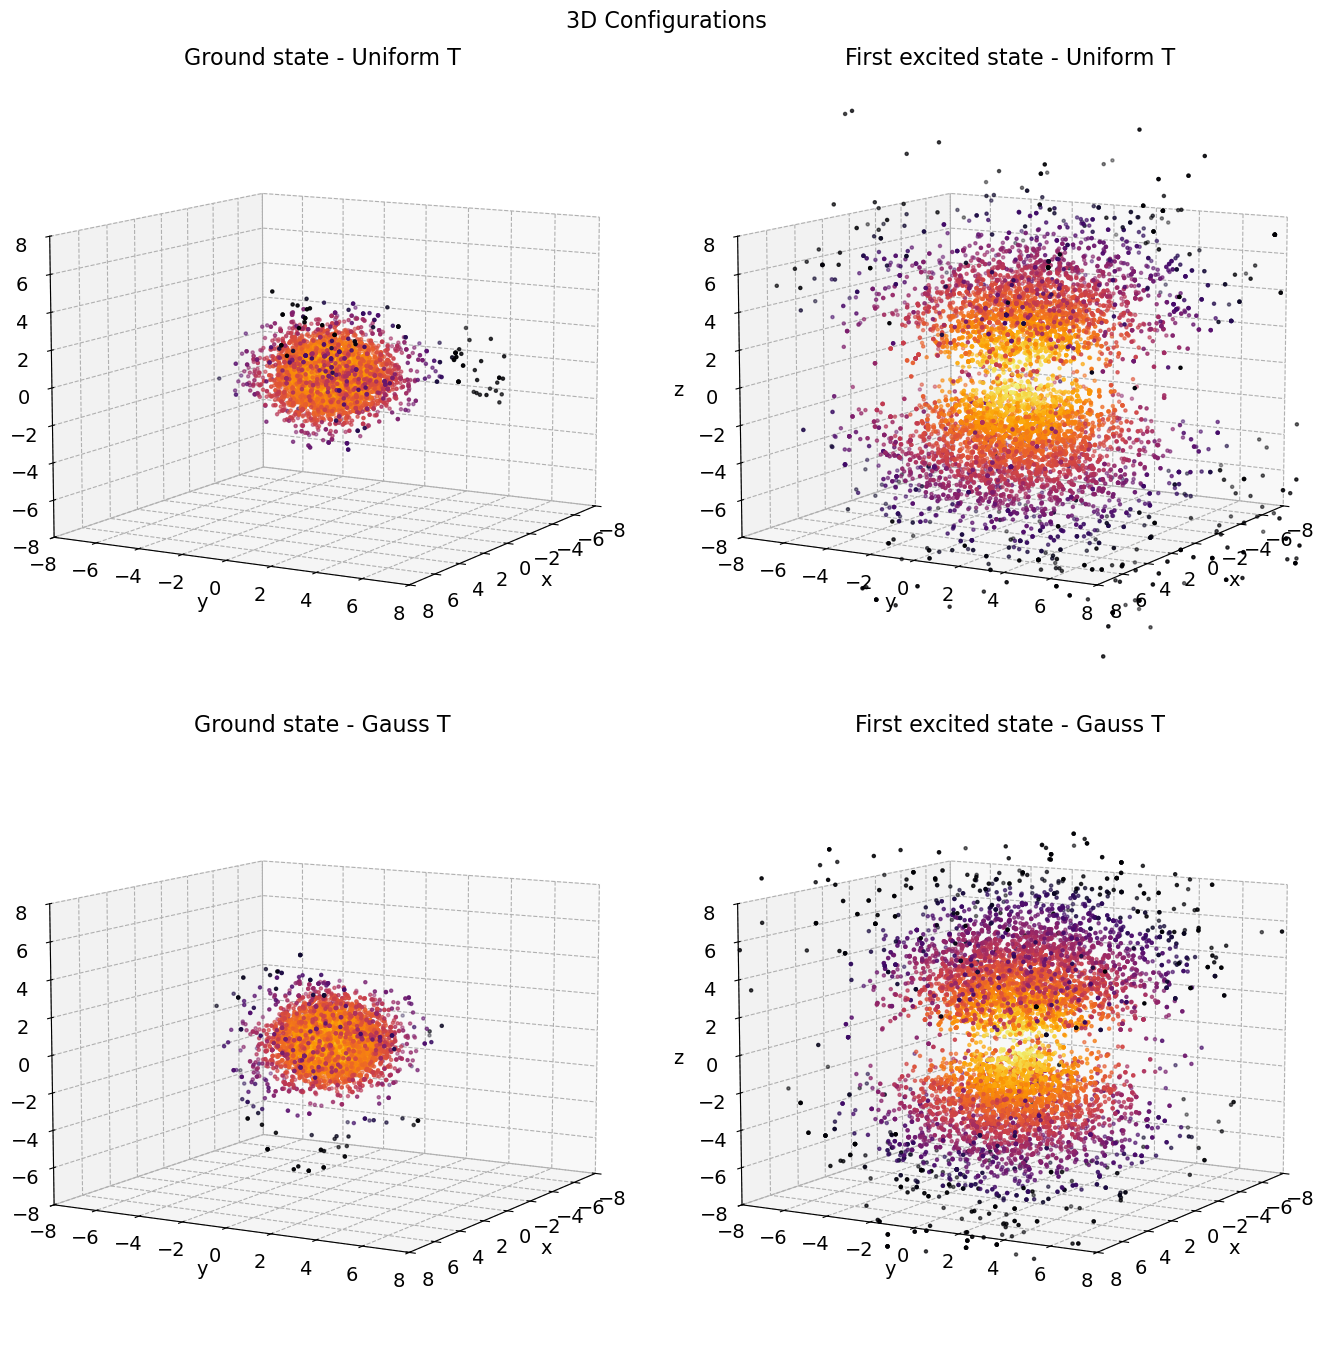

In [6]:

import matplotlib.cm as cm

folders_UNIF = ['OUTPUT_ground_unif', 'OUTPUT_excited_unif']
folders_GAUSS = ['OUTPUT_ground_Gauss', 'OUTPUT_excited_Gauss']
labels = ['Ground state - Uniform T', 'First excited state - Uniform T', 
          'Ground state - Gauss T', 'First excited state - Gauss T']

all_folders = folders_UNIF + folders_GAUSS

fig = plt.figure(figsize=(14, 14))

viridis = cm.get_cmap('inferno_r')

for i, (folder_name, label) in enumerate(zip(all_folders, labels)):
    file_path = f"NSL_SIMULATOR/{folder_name}/history.dat"

    data = np.loadtxt(file_path)
    X, Y, Z = data[:, 0], data[:, 1], data[:, 2]

    # Evaluate distance to use colormap
    norm = max(np.sqrt(X**2 + Y**2 + Z**2))
    rescaled = pow(np.sqrt(X**2 + Y**2 + Z**2), 1.2) / norm

    # I add a subplot 3D to a 2x2 lattice
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.scatter(X, Y, Z, marker='.', c=viridis(rescaled))
    
    ax.set_title(label)
    ax.set_xlim(-8, 8)
    ax.set_ylim(-8, 8)
    ax.set_zlim(-8, 8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.view_init(10, 30)

fig.suptitle("3D Configurations", fontsize=16)
fig.tight_layout()
plt.show()

It is possible to observe the first steps explored converging towards the origin in the first image! Then, it is also possible to appreciate the fascinating pdf of these hydrogen states. 